In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

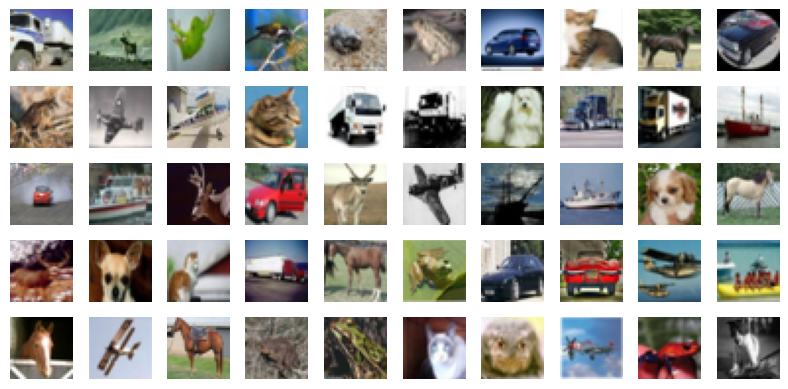

In [ ]:
T=1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_dim = 3 * 32 * 32
batch_size = 128

# CIFAR10: 32x32 RGB -> 3072 dim
transform = transforms.Compose([
    transforms.ToTensor(),  # [0, 1]
    transforms.Lambda(lambda x: x * 2. - 1.)  # [-1, 1]
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
images, labels = next(iter(train_loader))

# Возьмём первые 50
images_50 = images[:50]
labels_50 = labels[:50]

def denormalize(img_tensor):
    return img_tensor * 0.5 + 0.5  # Обратная нормализация из [-1,1] → [0,1]

fig, axs = plt.subplots(5, 10, figsize=(8, 4))
for i in range(50):
    img = denormalize(images_50[i])
    axs[i // 10, i % 10].imshow(img.permute(1, 2, 0).numpy())  # CxHxW → HxWxC
    axs[i // 10, i % 10].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
T = 1000  # количество шагов шума

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device) # variance schedule
alphas = (1. - betas).to(device)
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)  # \bar{\alpha}_t

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

import torch

T = 1000
betas = torch.linspace(1e-4, 0.02, T)  # PyTorch, не NumPy!
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

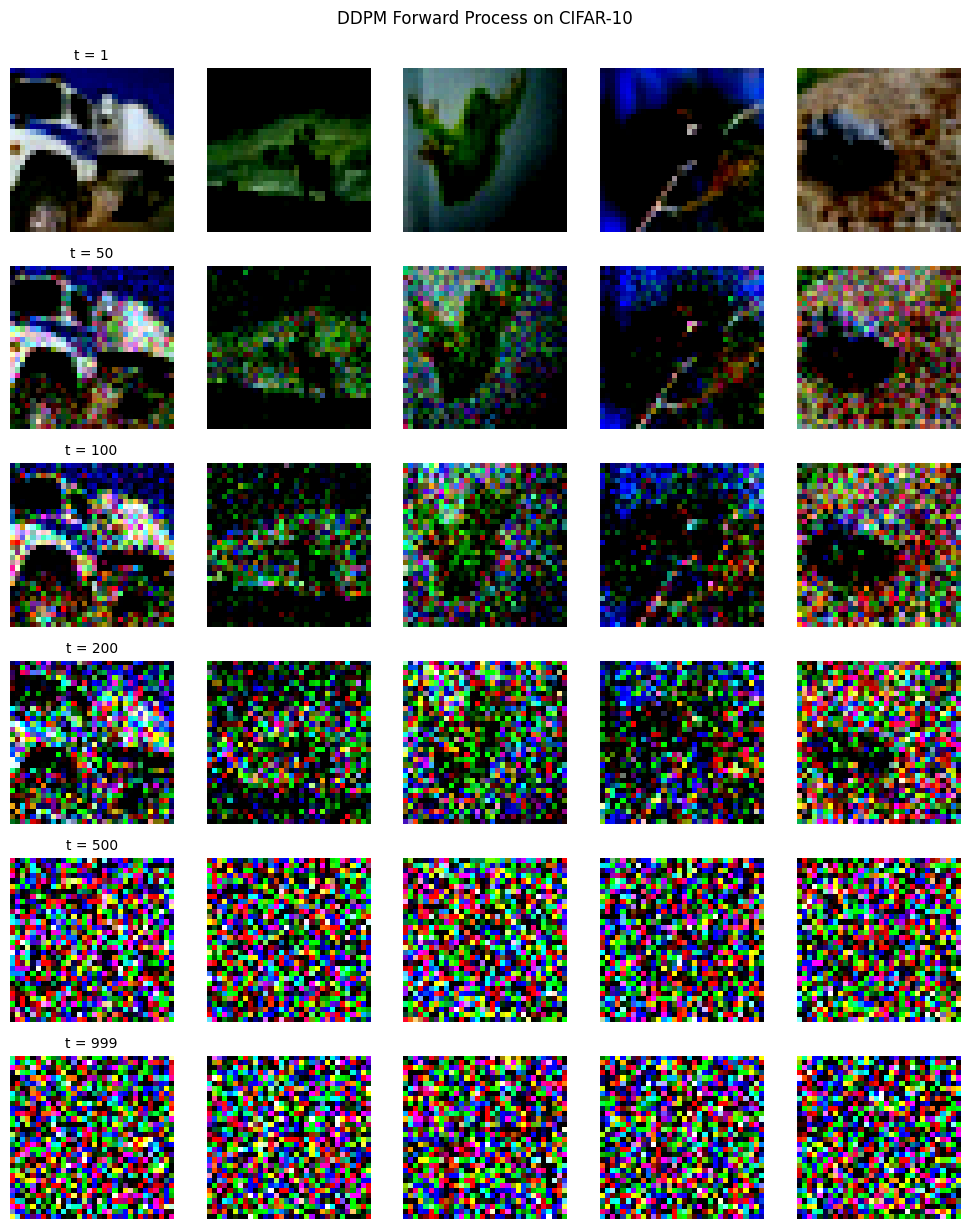

In [ ]:
def q_sample(x_0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_0)

    # Выбор нужного коэффициента по индексу t
    # t имеет shape [B], поэтому мы индексируем по батчу
    batch_size = t.shape[0]
    shape = [batch_size] + [1] * (x_0.dim() - 1)  # [B, 1, 1, 1]

    sqrt_alpha = sqrt_alphas_cumprod[t].view(shape)
    sqrt_one_minus_alpha = sqrt_one_minus_alphas_cumprod[t].view(shape)

    return sqrt_alpha * x_0 + sqrt_one_minus_alpha * noise

num_images = 5
timesteps = [1, 50, 100, 200, 500, 999]
# Визуализация
fig, axs = plt.subplots(len(timesteps), num_images, figsize=(num_images * 2, len(timesteps) * 2))
for row, t in enumerate(timesteps):
    x_0 = images[:num_images]  # <<<<< ВАЖНО: сократить батч
    t_tensor = torch.tensor([t] * num_images)
    noise = torch.randn_like(x_0)
    x_t = q_sample(x_0, t_tensor, noise).clamp(0, 1)
    for col in range(num_images):
        axs[row, col].imshow(np.transpose(x_t[col].cpu(), (1, 2, 0)))
        axs[row, col].axis('off')
        if col == 0:
            axs[row, col].set_title(f"t = {t}", fontsize=10)
plt.tight_layout()
plt.suptitle("DDPM Forward Process on CIFAR-10", y=1.02)
plt.show()


Training DDPM model (based on MLP)

In [ ]:
import torch.nn as nn

class MLPDiffusion(nn.Module):
    def __init__(self, img_dim, time_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim)
        )
        self.model = nn.Sequential(
            nn.Linear(img_dim + time_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, img_dim)
        )

    def forward(self, x, t):
        t_embed = self.time_mlp(t.unsqueeze(-1).float())  # [B, time_dim]
        x_flat = x.view(x.size(0), -1)                    # [B, 3072]
        x = torch.cat([x_flat, t_embed], dim=1)           # [B, 3072 + time_dim]
        return self.model(x)                              # [B, 3072]


model = MLPDiffusion(img_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_history = []

num_epochs = 5

for epoch in range(num_epochs):
    epoch_loss = 0
    for x_0, _ in train_loader:
        x_0 = x_0.to(device)
        t = torch.randint(0, T, (x_0.size(0),), device=device).long()
        noise = torch.randn_like(x_0)
        x_t = q_sample(x_0, t, noise)

        # Предсказание шума
        noise_pred = model(x_t, t)
        loss = F.mse_loss(noise_pred, noise.view(x_0.shape[0], -1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_0.size(0)

    avg_epoch_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_epoch_loss)
    print(f"Epoch {epoch + 1}/{num_epochs} — Loss: {avg_epoch_loss:.6f}")

torch.save(model.state_dict(), "ddpm_mlp.pth")
print("Модель сохранена в файл ddpm_mlp.pth")

plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="Train MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM MLP Training Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Training DDPM model (based on UNet)

In [ ]:
import torch.nn as nn

class ConvDiffusion(nn.Module):
    def __init__(self, in_channels=3, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim)
        )
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + 1, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, in_channels, 3, padding=1)
        )

    def forward(self, x, t):
        t_embed = self.time_mlp(t.unsqueeze(-1).float())  # [B, time_dim]
        t_map = t_embed[:, :, None, None].expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, t_map[:, 0:1, :, :]], dim=1)  # concatenate 1 channel of time info
        return self.conv(x)

model = ConvDiffusion().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_history = []

num_epochs = 30  # Лучше начать с 30

for epoch in range(num_epochs):
    epoch_loss = 0
    model.train()
    for step, (x_0, _) in enumerate(train_loader):
        x_0 = x_0.to(device)
        t = torch.randint(0, T, (x_0.size(0),), device=device).long()
        noise = torch.randn_like(x_0)

        x_t = q_sample(x_0, t, noise)
        noise_pred = model(x_t, t)

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_0.size(0)

        if step % 100 == 0:
            print(f"Epoch {epoch+1}, Step {step}, Loss: {loss.item():.4f}")

    avg_epoch_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_epoch_loss)
    print(f"✅ Epoch {epoch + 1}/{num_epochs} — Avg Loss: {avg_epoch_loss:.6f}")

torch.save(model.state_dict(), "ddpm_conv.pth")
print("Модель сохранена в файл ddpm_conv.pth")

plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="Train MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM Conv Training Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Epoch 1, Step 0, Loss: 8.9582
Epoch 1, Step 100, Loss: 0.8367
Epoch 1, Step 200, Loss: 0.2905
Epoch 1, Step 300, Loss: 0.1340
✅ Epoch 1/30 — Avg Loss: 0.538321
Epoch 2, Step 0, Loss: 0.1551
Epoch 2, Step 100, Loss: 0.1545
Epoch 2, Step 200, Loss: 0.1378
Epoch 2, Step 300, Loss: 0.1133
✅ Epoch 2/30 — Avg Loss: 0.138128
Epoch 3, Step 0, Loss: 0.1103
Epoch 3, Step 100, Loss: 0.1148
Epoch 3, Step 200, Loss: 0.0880
Epoch 3, Step 300, Loss: 0.1399
✅ Epoch 3/30 — Avg Loss: 0.117119
Epoch 4, Step 0, Loss: 0.0863
Epoch 4, Step 100, Loss: 0.1271
Epoch 4, Step 200, Loss: 0.1248
Epoch 4, Step 300, Loss: 0.0915
✅ Epoch 4/30 — Avg Loss: 0.103358
Epoch 5, Step 0, Loss: 0.0909
Epoch 5, Step 100, Loss: 0.0813
Epoch 5, Step 200, Loss: 0.0899
Epoch 5, Step 300, Loss: 0.0961
✅ Epoch 5/30 — Avg Loss: 0.095451
Epoch 6, Step 0, Loss: 0.0823
Epoch 6, Step 100, Loss: 0.0647
Epoch 6, Step 200, Loss: 0.0764
Epoch 6, Step 300, Loss: 0.0756
✅ Epoch 6/30 — Avg Loss: 0.087597
Epoch 7, Step 0, Loss: 0.1042
Epoch 7, S

Sampling Images

In [ ]:
model = MLPDiffusion(img_dim).to(device)
model.load_state_dict(torch.load("ddpm_mlp.pth", map_location=device))
model.eval()



MLPDiffusion(
  (time_mlp): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (model): Sequential(
    (0): Linear(in_features=3328, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=3072, bias=True)
  )
)

In [ ]:
@torch.no_grad()
def p_sample(model, x_t, t):
    """
    Один шаг обратного диффузионного процесса
    x_t: [B, C, H, W]
    t: [B] — Tensor, значения в диапазоне [0, T)
    """
    batch_size = x_t.shape[0]
    shape = [batch_size] + [1] * (x_t.dim() - 1)  # [B, 1, 1, 1]

    # Индексация коэффициентов по каждому элементу батча
    beta_t = betas[t].reshape(shape)
    alpha_t = alphas[t].reshape(shape)
    alpha_cumprod_t = alphas_cumprod[t].reshape(shape)
    sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1 - alpha_cumprod_t)
    sqrt_recip_alpha_t = torch.rsqrt(alpha_t)  # 1 / sqrt(alpha)

    # Предсказание шума
    eps_theta = model(x_t, t)

    # Формула DDPM
    model_mean = sqrt_recip_alpha_t * (x_t - (beta_t / sqrt_one_minus_alpha_cumprod_t) * eps_theta)

    # Добавляем шум (кроме финального шага)
    noise = torch.randn_like(x_t)
    nonzero_mask = (t != 0).float().reshape(shape)  # чтобы не добавлять шум на t=0
    sample = model_mean + nonzero_mask * torch.sqrt(beta_t) * noise

    return sample


In [ ]:
# @torch.no_grad()
# def p_sample_loop(model, shape, device):
#     x = torch.randn(shape, device=device)  # x_T ~ N(0, I)
#     for t in reversed(range(T)):
#         x = p_sample(model, x, t)
#     return x

@torch.no_grad()
def p_sample_loop(model, shape, device):
    x = torch.randn(shape, device=device)  # x_T ~ N(0, I)
    for t in reversed(range(T)):
        t_batch = torch.full((x.shape[0],), t, device=device, dtype=torch.long)
        x = p_sample(model, x, t_batch)
    return x



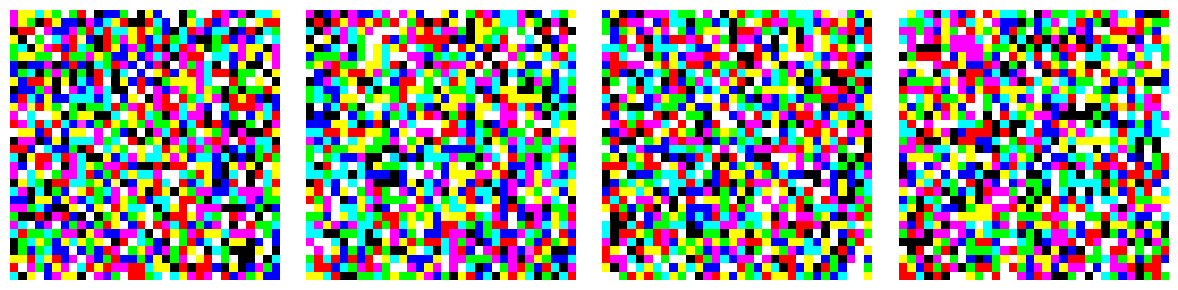

In [ ]:
@torch.no_grad()
def generate_images(model, num_images=4):
    samples = p_sample_loop(model, shape=(num_images, img_dim), device=device)
    images = samples.view(-1, 3, 32, 32).clamp(-1, 1)
    images = (images + 1) / 2  # [-1, 1] → [0, 1]
    return images.cpu()

def show_images(images):
    plt.figure(figsize=(12, 3))
    for i in range(images.shape[0]):
        plt.subplot(1, images.shape[0], i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# 🚀 Генерация и визуализация
generated_imgs = generate_images(model, num_images=4)
show_images(generated_imgs)
